# Numerical Primitives — Milestone 6

Every thermodynamic calculation in later milestones bottoms out in one of a handful of numerical operations: rooting a cubic in Z, finding the temperature that makes a residual zero, iterating a multi-variable system to convergence in a flash. Milestone 6 ships all of those primitives in one place — `engine/src/numerics/` — with tests, PyO3 bindings, and the (12) Poling & Prausnitz / Brent / Halley / Broyden algorithm choices spelled out in [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/docs/plans/MODERNIZATION_PLAN.md). This notebook walks each primitive with a runnable example.

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel — useful when running locally to make sure you're testing against the published wheel, exactly the way a downstream user would.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context — what the legacy code did vs. what M6 ships

The VB6 and Pascal sources hand-rolled their numerical methods inline with each thermodynamic routine. The [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/docs/plans/MODERNIZATION_PLAN.md) *Algorithm Choices* section spells out which legacy choices we kept and which we replaced. The M6 surface implements the
replacements:

| Legacy | M6 replacement | Why |
|---|---|---|
| Hand-rolled Cardano (`McommonFunctions.bas:324`) | `solve_cubic` + (12) Poling/Prausnitz robustness | Stable across the critical-point discriminant boundary. |
| Regula Falsi (`clsSatPressureSolver.cls`) | `brent` (default) + `illinois` | Super-linear convergence with bisection fallback. |
| Newton-Raphson inline | `halley` + `broyden` | Halley: cubic convergence for scalar Rachford-Rice. Broyden: rank-1 update + periodic refresh for the multi-variable flash, K=5 steps between refreshes per the §F default. |
| Hand-rolled Gauss elimination (`McommonFunctions.bas:24`) | `nalgebra::DMatrix.lu()` (used inside `broyden`) | LU with partial pivoting + parallel BLAS backends. |

Each algorithm is small enough to read in one sitting — see [`engine/src/numerics/`](https://github.com/miguelju/vle/tree/main/engine/src/numerics).

## What was built in Milestone 6

Five primitives, each exposed as both a Rust function (engine-side) and a `vle._engine` PyO3 binding (Python-side). The Python names are flat — `from vle._engine import solve_cubic, brent, …` — so the higher-level `vle` wrapper can re-export them into themed submodules later without changing the binding shape.

1. **`solve_cubic(a, b, c, d)`** — Cardano + (12) Poling robustness;    returns every real root of `a·x³ + b·x² + c·x + d = 0` in    ascending order.
2. **`brent(f, a, b, …)`** — Brent's bracketed scalar root finder.    Default for `f(x) = 0` when you can bracket the answer.
3. **`illinois(f, a, b, …)`** — Lighter modified-Regula-Falsi    alternative with weight halving on stalls.
4. **`halley(f_and_derivs, x0, …)`** — Cubic-convergence Newton++    when you have analytical `f`, `f'`, `f''`. Used in M9's    Rachford-Rice.
5. **`broyden(f, x0, …)`** — Quasi-Newton for multi-variable    systems. Rank-1 secant updates + periodic finite-difference    refresh every K=5 steps. The workhorse for M9 flash.

Plus utility functions exposed for parity with the Rust side: `sum_frac_residual`, `norm_l1`, `norm_l2`, `norm_linf`. Everything in the rest of this notebook is built on these eight names.

## Setup

Pull every binding we'll use, plus matplotlib for the convergence plots.

In [2]:
import math

import matplotlib.pyplot as plt

from vle._engine import (
    brent,
    broyden,
    halley,
    illinois,
    norm_l2,
    solve_cubic,
    sum_frac_residual,
    version,
)

print(f'vle._engine version: {version()}')

vle._engine version: 0.1.2


## 1. Cardano on a Z-factor-style cubic

A cubic equation of state (Peng-Robinson, RKS, …) reduces to a cubic in the compressibility factor `Z`. When the EOS yields **three** real roots, the smallest is the liquid `Z`, the largest is the vapor `Z`, and the middle root is thermodynamically unstable. `solve_cubic` returns every real root sorted ascending; we pick the right extreme with `min` / `max`.

The cubic below is constructed from known roots so we can compare against an exact answer:
$$ (Z - 0.10)(Z - 0.15)(Z - 0.80) = Z^3 - 1.05\,Z^2 + 0.215\,Z - 0.012 $$

In [3]:
coeffs = (1.0, -1.05, 0.215, -0.012)
roots = solve_cubic(*coeffs)
print(f'all roots (ascending): {roots}')
print(f'liquid Z (smallest) : {min(roots):.4f}')
print(f'vapor  Z (largest)  : {max(roots):.4f}')

# Residual sanity check — plug each root back into the polynomial
for r in roots:
    a, b, c, d = coeffs
    residual = ((a*r + b)*r + c)*r + d
    print(f'  residual at Z={r:.4f}: {residual:+.2e}')

assert math.isclose(min(roots), 0.10, abs_tol=1e-10)
assert math.isclose(max(roots), 0.80, abs_tol=1e-10)

all roots (ascending): [0.10000000000000028, 0.14999999999999977, 0.8]
liquid Z (smallest) : 0.1000
vapor  Z (largest)  : 0.8000
  residual at Z=0.1000: +1.04e-17
  residual at Z=0.1500: +5.20e-18
  residual at Z=0.8000: -1.04e-17


## 2. Brent vs. Illinois — convergence on the Dottie number

Both `brent` and `illinois` solve `f(x) = 0` on a bracketed interval. Brent combines bisection, secant, and inverse-quadratic interpolation; Illinois is a lighter modified-Regula-Falsi. On smooth problems Brent typically wins on iteration count.

Counting iterations is the cleanest way to see the difference. We wrap each function in a counting closure, find the Dottie number (`cos(x) − x = 0`, root ≈ 0.7390851332), and read off how many evaluations each algorithm took at a range of tolerances.

      xtol    Brent   Illinois
     1e-03        6          9
     1e-06       11          9
     1e-09        9          9
     1e-12        9          9
     1e-15        9          9


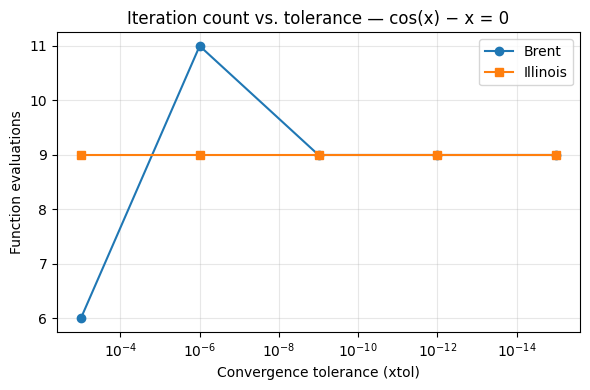

In [4]:
def count_calls(f):
    """Wrap f so the .calls attribute reports invocation count."""
    def wrapped(x):
        wrapped.calls += 1
        return f(x)
    wrapped.calls = 0
    return wrapped

tolerances = [1e-3, 1e-6, 1e-9, 1e-12, 1e-15]
brent_counts = []
illinois_counts = []
for tol in tolerances:
    f_b = count_calls(lambda x: math.cos(x) - x)
    brent(f_b, 0.0, 1.0, tol, 100)
    brent_counts.append(f_b.calls)

    f_i = count_calls(lambda x: math.cos(x) - x)
    illinois(f_i, 0.0, 1.0, tol, 100)
    illinois_counts.append(f_i.calls)

print(f'{"xtol":>10} {"Brent":>8} {"Illinois":>10}')
for tol, b, i in zip(tolerances, brent_counts, illinois_counts):
    print(f'{tol:>10.0e} {b:>8} {i:>10}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(tolerances, brent_counts, 'o-', label='Brent')
ax.semilogx(tolerances, illinois_counts, 's-', label='Illinois')
ax.set_xlabel('Convergence tolerance (xtol)')
ax.set_ylabel('Function evaluations')
ax.set_title('Iteration count vs. tolerance — cos(x) − x = 0')
ax.legend(); ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # tighter tolerance on the right
fig.tight_layout()
plt.show()

## 3. Halley vs. Newton — convergence-rate comparison

Halley's method buys you cubic convergence (≈ tripling the number of correct digits per iteration on smooth `f`) for the cost of one extra derivative evaluation per step. Newton-Raphson is only quadratic. On well-behaved problems the gap shows up after just a few iterations.

Solving `x² − 612 = 0` starting from `x = 10` is the textbook demonstration. We implement bare Newton in Python (we don't ship it — Halley is the default in the engine), count both, and confirm Halley needs fewer evaluations.

In [5]:
def newton(f, df, x0, ftol, max_iter):
    """Plain Newton-Raphson for comparison. Halley is in the wheel.
    Convergence on residual size (not step size) so we don't hit
    the sub-ULP floor on this well-conditioned problem.
    """
    x = x0
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < ftol:
            return x, i
        x = x - fx / df(x)
    raise RuntimeError('Newton: no convergence')

# Halley with the engine's default tolerance (xtol=1e-12, max_iter=50)
halley_iters = 0
def halley_callback(x):
    global halley_iters
    halley_iters += 1
    return (x*x - 612.0, 2.0*x, 2.0)

halley_root = halley(halley_callback, 10.0)
newton_root, newton_iters = newton(
    lambda x: x*x - 612.0,
    lambda x: 2.0*x,
    10.0, 1e-12, 50,
)

true_sqrt = math.sqrt(612.0)
print(f'true value     : √612 = {true_sqrt}')
print(f'Halley result  : {halley_root}  (after {halley_iters} iters)')
print(f'Newton result  : {newton_root}  (after {newton_iters} iters)')

assert math.isclose(halley_root, true_sqrt, rel_tol=1e-12)
assert math.isclose(newton_root, true_sqrt, rel_tol=1e-6)
assert halley_iters < newton_iters, (
    f'expected Halley to beat Newton; got {halley_iters} vs {newton_iters}'
)

true value     : √612 = 24.73863375370596
Halley result  : 24.73863375370596  (after 5 iters)
Newton result  : 24.73863375370596  (after 6 iters)


## 4. Broyden on a 2-equation nonlinear system

`broyden` solves `F(x) = 0` where `F: ℝⁿ → ℝⁿ`. Each iteration: solve `J · Δx = −F` for the step, update `x`, then do a **rank-1 secant update** of `J` instead of recomputing it from scratch. Every K=5 iterations (configurable) we refresh `J` via finite differences to keep the approximation honest.

The system below has a closed-form root we can check against:
$$ x^2 + y^2 = 2, \qquad x \cdot y = 1 \;\;\Longrightarrow\;\; (x, y) = (1, 1) $$

In [6]:
def F(v):
    x, y = v
    return [x*x + y*y - 2.0, x*y - 1.0]

root = broyden(F, [0.5, 1.5], xtol=1e-14, ftol=1e-14)
print(f'Broyden root: ({root[0]:.10f}, {root[1]:.10f})')
print(f'F at root   : {F(root)}')

assert math.isclose(root[0], 1.0, abs_tol=1e-6)
assert math.isclose(root[1], 1.0, abs_tol=1e-6)
# ‖F‖ should be near zero — every component a clean residual
assert norm_l2(F(root)) < 1e-10

Broyden root: (0.9999999582, 1.0000000418)
F at root   : [3.1086244689504383e-15, -1.9984014443252818e-15]


## Your turn — exercises

Two short exercises calling into the M6 surface. Template cells have `# TODO` markers; solutions are in the collapsed block at the bottom of the notebook.

### Exercise 1 — Find the vapor Z of a custom cubic

You're given an EOS cubic in `Z` with coefficients
`(a, b, c, d) = (1.0, -1.42, 0.59, -0.045)`. Use `solve_cubic` to find every real root, then pick the **vapor** root (the largest one) and confirm it satisfies the cubic to within 1e-10.

Bonus: also compute the liquid root and print the ratio `Z_vapor / Z_liquid`.

In [7]:
# TODO: roots = solve_cubic(1.0, -1.42, 0.59, -0.045)
# TODO: z_vapor = max(roots)
# TODO: assert abs(((a*z + b)*z + c)*z + d) < 1e-10

# your code here


### Exercise 2 — Solve a custom 2-equation system with Broyden

Define the residual function:
$$ F(x, y) = \bigl(\; e^x + y - 5, \quad x + e^y - 5 \;\bigr) $$

and use `broyden` (with default tolerances) to find a root starting from `[1.0, 1.0]`. Verify `‖F(root)‖₂ < 1e-7`.

This is a small but genuinely non-quadratic system — the kind of shape M9's flash residuals will have.

In [8]:
# TODO: import math
# TODO: def F(v):
#           x, y = v
#           return [math.exp(x) + y - 5.0, x + math.exp(y) - 5.0]
# TODO: root = broyden(F, [1.0, 1.0])
# TODO: assert norm_l2(F(root)) < 1e-7

# your code here


### Solutions (expand to see)

<details>
<summary>Click to show Exercise 1 solution</summary>

```python
a, b, c, d = 1.0, -1.42, 0.59, -0.045
roots = solve_cubic(a, b, c, d)
print(f'all real roots: {roots}')
z_vapor = max(roots)
z_liquid = min(roots)
print(f'vapor Z : {z_vapor:.6f}')
print(f'liquid Z: {z_liquid:.6f}')
print(f'ratio   : {z_vapor / z_liquid:.2f}')
residual = ((a*z_vapor + b)*z_vapor + c)*z_vapor + d
assert abs(residual) < 1e-10, residual
```

</details>

<details>
<summary>Click to show Exercise 2 solution</summary>

```python
def F(v):
    x, y = v
    return [math.exp(x) + y - 5.0, x + math.exp(y) - 5.0]

root = broyden(F, [1.0, 1.0])
print(f'root: ({root[0]:.6f}, {root[1]:.6f})')
print(f'F(root) L2 norm: {norm_l2(F(root)):.2e}')
assert norm_l2(F(root)) < 1e-7
```

</details>

## References

- **Modernization plan**: [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/docs/plans/MODERNIZATION_PLAN.md) *Algorithm Choices* (§A–§H) — rationale for every M6 algorithm pick.
- **Source**: [`engine/src/numerics/`](https://github.com/miguelju/vle/tree/main/engine/src/numerics) — each algorithm lives in its own file with a module-level doc-comment.
- **PyO3 bindings**: [`engine/src/py_bindings.rs`](https://github.com/miguelju/vle/blob/main/engine/src/py_bindings.rs) — the M6 surface lives in the same file as the rest of `vle._engine`.
- (12) Poling, B. E.; Prausnitz, J. M.; O'Connell, J. P., *The Properties of Gases and Liquids* (5th ed.), §4-6 — discriminant-robustness recommendation for cubic-EOS Cardano.
- Brent, R. P. (1971), *An algorithm with guaranteed convergence for finding a zero of a function*.
- Halley, E. (1694), *A new, exact, and easy method of finding the roots of any equations generally*.
- Broyden, C. G. (1965), *A class of methods for solving nonlinear simultaneous equations*.
- Press, W. H. et al., *Numerical Recipes* (3rd ed.), §9.4 (Halley) and §9.7 (Broyden) — modern restatements with implementation notes.